In [23]:
import pandas as pd
import numpy as np
import seaborn as sns

In [39]:
df = pd.read_csv('english.csv')

In [40]:
df

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0
...,...,...
3405,Img/img062-051.png,z
3406,Img/img062-052.png,z
3407,Img/img062-053.png,z
3408,Img/img062-054.png,z


In [41]:
df.head()

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [42]:
df.shape

(3410, 2)

In [43]:
df.describe()

,image,label
count,3410,3410
unique,3410,62
top,Img/img001-001.png,0
freq,1,55


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   image   3410 non-null   str  
 1   label   3410 non-null   str  
dtypes: str(2)
memory usage: 53.4 KB


In [45]:
df.columns

Index(['image', 'label'], dtype='str')

In [46]:
df.dtypes

image    str
label    str
dtype: object

In [47]:
df.isnull().sum()

image    0
label    0
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
print("Total images:", len(df))

print("Labels:")
print(df["label"].unique())

print("\nEach label count:")
print(df["label"].value_counts())

Total images: 3410
Labels:
<StringArray>
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E',
 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i',
 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x',
 'y', 'z']
Length: 62, dtype: str

Each label count:
label
0    55
1    55
2    55
3    55
4    55
     ..
v    55
w    55
x    55
y    55
z    55
Name: count, Length: 62, dtype: int64


In [50]:
characters = sorted(df["label"].unique())

char_to_number = {}

for i, char in enumerate(characters):
    char_to_number[char] = i

print(char_to_number)

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'A': 10, 'B': 11, 'C': 12, 'D': 13, 'E': 14, 'F': 15, 'G': 16, 'H': 17, 'I': 18, 'J': 19, 'K': 20, 'L': 21, 'M': 22, 'N': 23, 'O': 24, 'P': 25, 'Q': 26, 'R': 27, 'S': 28, 'T': 29, 'U': 30, 'V': 31, 'W': 32, 'X': 33, 'Y': 34, 'Z': 35, 'a': 36, 'b': 37, 'c': 38, 'd': 39, 'e': 40, 'f': 41, 'g': 42, 'h': 43, 'i': 44, 'j': 45, 'k': 46, 'l': 47, 'm': 48, 'n': 49, 'o': 50, 'p': 51, 'q': 52, 'r': 53, 's': 54, 't': 55, 'u': 56, 'v': 57, 'w': 58, 'x': 59, 'y': 60, 'z': 61}


In [51]:
df["number"] = df["label"].map(char_to_number)

print(df.head())

                image label  number
0  Img/img001-001.png     0       0
1  Img/img001-002.png     0       0
2  Img/img001-003.png     0       0
3  Img/img001-004.png     0       0
4  Img/img001-005.png     0       0


In [52]:
numbers = df["number"].tolist()

X = []
y = []

for i in range(len(numbers) - 1):
    X.append(numbers[i])
    y.append(numbers[i + 1])

print("X:", X[:10])
print("y:", y[:10])

X: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
y: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [53]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3409,)
y shape: (3409,)


In [54]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 2727
Testing data: 682


In [55]:
X_train = X_train.reshape(-1, 1, 1)
X_test = X_test.reshape(-1, 1, 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2727, 1, 1)
X_test shape: (682, 1, 1)


In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(32, input_shape=(1, 1)))
model.add(Dense(62, activation='softmax'))

print(model.summary())

C:\Users\anand\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 62)                  │           2,046 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,398 (24.99 KB)

 Trainable params: 6,398 (24.99 KB)

 Non-trainable params: 0 (0.00 B)

None


In [57]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model is ready!")

Model is ready!


In [58]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test))

Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0422 - loss: 4.0295 - val_accuracy: 0.0000e+00 - val_loss: 4.8626
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0473 - loss: 3.7881 - val_accuracy: 0.0000e+00 - val_loss: 5.7232
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0616 - loss: 3.5974 - val_accuracy: 0.0000e+00 - val_loss: 6.1826
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0814 - loss: 3.4589 - val_accuracy: 0.0000e+00 - val_loss: 6.5762
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1074 - loss: 3.3476 - val_accuracy: 0.0000e+00 - val_loss: 6.9177
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1914 - loss: 3.2497 - val_accuracy: 0.0000e+00 - val_loss: 7.2079
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1918 - loss: 3.1618 - val_accuracy: 0.0000e+00 - val_loss: 7.4318
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1830 - loss: 3.0847 - val

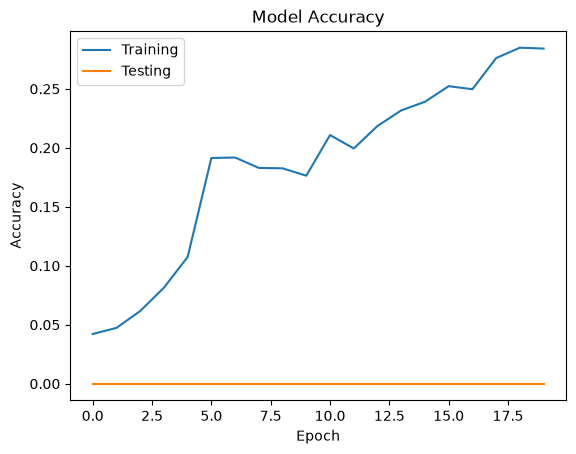

In [59]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Testing"])
plt.show()

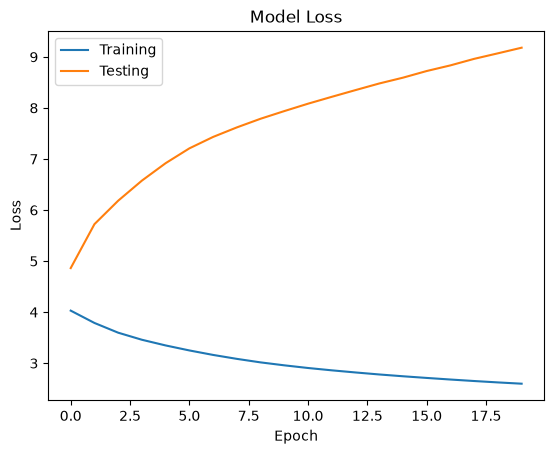

In [60]:
# Loss graph
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training", "Testing"])
plt.show()

In [61]:
text = ''.join(df["label"].tolist())

X = []
y = []

for i in range(len(text) - 5):
    X.append(text[i:i+5])
    y.append(text[i+5])

print("First input:", X[0])
print("First output:", y[0])

First input: 00000
First output: 0


In [62]:
X_number = []

for sequence in X:
    temp = []

    for char in sequence:
        temp.append(char_to_number[char])

    X_number.append(temp)

X_number = np.array(X_number)
y_number = np.array([char_to_number[char] for char in y])

print("X shape:", X_number.shape)
print("y shape:", y_number.shape)

X shape: (3405, 5)
y shape: (3405,)


In [63]:

X_number = X_number.reshape(-1, 5, 1)

print("New X shape:", X_number.shape)

New X shape: (3405, 5, 1)


In [64]:


split = int(len(X_number) * 0.8)

X_train = X_number[:split]
X_test = X_number[split:]

y_train = y_number[:split]
y_test = y_number[split:]

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 2724
Testing: 681


In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


model = Sequential()

model.add(LSTM(64, input_shape=(5, 1)))
model.add(Dense(62, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 62)                  │           4,030 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,926 (81.74 KB)

 Trainable params: 20,926 (81.74 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model ready!")

Model ready!


In [67]:

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0507 - loss: 3.7438 - val_accuracy: 0.0000e+00 - val_loss: 5.1452
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1512 - loss: 3.0073 - val_accuracy: 0.0000e+00 - val_loss: 5.7272
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2511 - loss: 2.6113 - val_accuracy: 0.0000e+00 - val_loss: 6.2383
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3443 - loss: 2.3771 - val_accuracy: 0.0000e+00 - val_loss: 6.8405
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4108 - loss: 2.2147 - val_accuracy: 0.0000e+00 - val_loss: 7.2215
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4079 - loss: 2.0744 - val_accuracy: 0.0000e+00 - val_loss: 7.6010
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4446 - loss: 1.9622 - val_accuracy: 0.0000e+00 - val_loss: 7.9337
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4916 - loss: 1.8650 - val

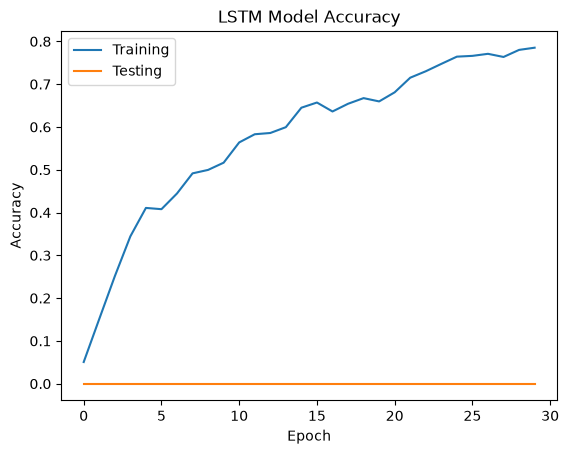

In [68]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Testing"])

plt.show()


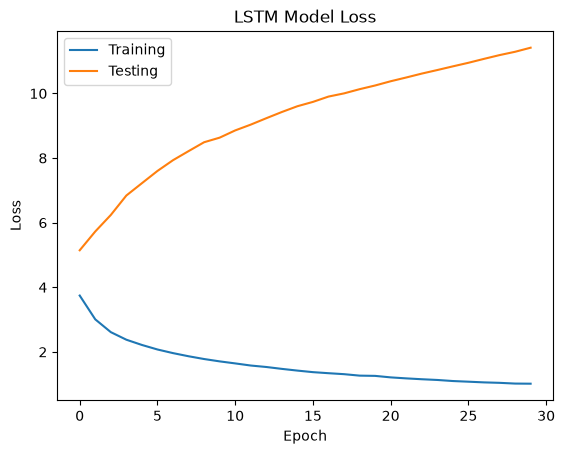

In [69]:
# Loss graph
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Testing"])

plt.show()

In [70]:


input_text = "ABCDE"

input_numbers = []

for char in input_text:
    input_numbers.append(char_to_number[char])

input_numbers = np.array(input_numbers)
input_numbers = input_numbers.reshape(1, 5, 1)


prediction = model.predict(input_numbers, verbose=0)

predicted_number = np.argmax(prediction)

predicted_character = characters[predicted_number]

print("Input:", input_text)
print("Predicted next character:", predicted_character)

Input: ABCDE
Predicted next character: C


In [72]:


input_text = "ABCDE"
generated_text = input_text

for i in range(20):

    input_numbers = []

    for char in input_text:
        input_numbers.append(char_to_number[char])

    input_numbers = np.array(input_numbers)
    input_numbers = input_numbers.reshape(1, 5, 1)

    prediction = model.predict(input_numbers, verbose=0)

    predicted_number = np.argmax(prediction)
    predicted_character = characters[predicted_number]

    generated_text = generated_text + predicted_character

    
    input_text = generated_text[-5:]

print("Generated text:", generated_text)

Generated text: ABCDECCDDDCDDDDDDDDDDDDDD


In [73]:

model.save("character_lstm_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [74]:
input_text = "HELLO"

input_numbers = []

for char in input_text:
    input_numbers.append(char_to_number[char])

input_numbers = np.array(input_numbers)
input_numbers = input_numbers.reshape(1, 5, 1)

prediction = model.predict(input_numbers, verbose=0)

predicted_number = np.argmax(prediction)
predicted_character = characters[predicted_number]

print("Input:", input_text)
print("Predicted next character:", predicted_character)

Input: HELLO
Predicted next character: G
